# 01 — German Credit: First EDA

**Goal of this notebook:** load our first real credit dataset, decode it into human-readable
form, and run the exploratory data analysis (EDA) that every credit-scoring project starts with.

By the end you'll have seen, with your own eyes:
- what a raw credit dataset actually looks like,
- why **class imbalance** makes *accuracy* a misleading metric,
- how numeric features (age, loan amount, duration) are distributed,
- and the single most important EDA move in credit scoring: **default rate by category**.

Two cells are marked `TODO (YOU)` — those are for you to fill in. Everything else is explained
above the code. Read the markdown, run the cell, look at the output, then move on.

Run each cell with **Shift+Enter**.

## 1. Imports

`pandas` is the table/dataframe library — think Excel in Python. `numpy` is fast math on arrays.
`matplotlib` + `seaborn` draw charts. The `%matplotlib inline` line tells Jupyter to draw plots
right inside the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.5.1


## 2. The schema (what the columns and codes mean)

The raw file has no header row, and its categorical values are codes like `A11`, `A34`.
The dataset documentation (`german.doc`) tells us what each column and each code means.
We encode that knowledge here so the rest of the notebook is readable.

`COLUMNS` = the 20 feature names + the target, in file order.
`CODE_MAP` = for each coded column, what each code translates to.

In [3]:
COLUMNS = [
    "checking_status",      # A11..A14  (ordered: balance in the checking account)
    "duration_months",      # numeric
    "credit_history",       # A30..A34
    "purpose",              # A40..A410
    "credit_amount",        # numeric (Deutsche Mark)
    "savings_status",       # A61..A65 (ordered-ish)
    "employment_since",     # A71..A75 (ordered)
    "installment_rate",     # numeric: % of disposable income
    "personal_status_sex",  # A91..A95
    "other_debtors",        # A101..A103
    "residence_since",      # numeric: years at current residence
    "property",             # A121..A124
    "age_years",            # numeric
    "other_installment",    # A141..A143
    "housing",              # A151..A153
    "existing_credits",     # numeric: # credits at this bank
    "job",                  # A171..A174
    "num_dependents",       # numeric
    "telephone",            # A191..A192
    "foreign_worker",       # A201..A202
    "target",               # 1 = good (repaid), 2 = bad (defaulted)
]

CODE_MAP = {
    "checking_status": {"A11": "< 0 DM", "A12": "0-200 DM", "A13": ">= 200 DM", "A14": "no account"},
    "credit_history": {
        "A30": "no credits/all paid", "A31": "all paid this bank",
        "A32": "paid duly till now", "A33": "past delays", "A34": "critical/other credits"},
    "purpose": {
        "A40": "car (new)", "A41": "car (used)", "A42": "furniture/equip",
        "A43": "radio/tv", "A44": "appliances", "A45": "repairs", "A46": "education",
        "A47": "vacation", "A48": "retraining", "A49": "business", "A410": "other"},
    "savings_status": {
        "A61": "< 100 DM", "A62": "100-500 DM", "A63": "500-1000 DM",
        "A64": ">= 1000 DM", "A65": "unknown/none"},
    "employment_since": {
        "A71": "unemployed", "A72": "< 1 yr", "A73": "1-4 yrs",
        "A74": "4-7 yrs", "A75": ">= 7 yrs"},
    "personal_status_sex": {
        "A91": "male div/sep", "A92": "female div/sep/mar", "A93": "male single",
        "A94": "male mar/wid", "A95": "female single"},
    "other_debtors": {"A101": "none", "A102": "co-applicant", "A103": "guarantor"},
    "property": {
        "A121": "real estate", "A122": "life insurance", "A123": "car/other",
        "A124": "unknown/none"},
    "other_installment": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for free"},
    "job": {
        "A171": "unempl/unskilled-nonres", "A172": "unskilled-res",
        "A173": "skilled", "A174": "management/self-emp"},
    "telephone": {"A191": "none", "A192": "yes"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}
print(f"{len(COLUMNS)} columns defined, {len(CODE_MAP)} coded columns")

21 columns defined, 13 coded columns


## 3. Load the data

The file is space-separated with no header. We pass our column names in. The path is relative
to the `notebooks/` folder, so we go up one level (`..`) to reach `data/raw/`.

In [4]:
df = pd.read_csv(
    "../data/raw/german.data",
    sep=r"\s+",          # one or more spaces separate values
    header=None,
    names=COLUMNS,
)
print("shape:", df.shape)        # (rows, columns) -> expect (1000, 21)
df.head()

shape: (1000, 21)


,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment_since,installment_rate,personal_status_sex,other_debtors,residence_since,property,age_years,other_installment,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


## 4. First inspection

`.info()` shows each column's type and how many non-null values it has. Notice pandas guessed
`object` (text) for the coded columns and `int64` for the numeric ones. No missing values here —
German Credit is clean, which is exactly why the brief starts us here before the messy datasets.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   checking_status      1000 non-null   str  
 1   duration_months      1000 non-null   int64
 2   credit_history       1000 non-null   str  
 3   purpose              1000 non-null   str  
 4   credit_amount        1000 non-null   int64
 5   savings_status       1000 non-null   str  
 6   employment_since     1000 non-null   str  
 7   installment_rate     1000 non-null   int64
 8   personal_status_sex  1000 non-null   str  
 9   other_debtors        1000 non-null   str  
 10  residence_since      1000 non-null   int64
 11  property             1000 non-null   str  
 12  age_years            1000 non-null   int64
 13  other_installment    1000 non-null   str  
 14  housing              1000 non-null   str  
 15  existing_credits     1000 non-null   int64
 16  job                  1000 non-null  

`.describe()` gives summary statistics for the numeric columns. Look at `credit_amount`: the
mean and the max are far apart — a sign the distribution is right-skewed (a few very large loans).
We'll confirm that visually in a moment.

In [6]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_since,age_years,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


## 5. Decode the target, then the categoricals

**Credit-scoring convention:** the thing we predict is *default*. In this file `1 = good`,
`2 = bad`. We convert that into a clean 0/1 column called `default` where **1 means the borrower
defaulted (bad)** and 0 means they repaid (good). Models want 0/1, and "1 = the event of interest"
is the standard.

In [7]:
df["default"] = (df["target"] == 2).astype(int)   # 1 = defaulted, 0 = repaid
df[["target", "default"]].value_counts()

target  default
1       0          700
2       1          300
Name: count, dtype: int64

Now translate every coded column into readable labels using `CODE_MAP`. After this,
`df["checking_status"]` reads `"< 0 DM"` instead of `"A11"`.

In [8]:
for col, mapping in CODE_MAP.items():
    df[col] = df[col].map(mapping)

df[["checking_status", "credit_history", "purpose", "savings_status"]].head()

,checking_status,credit_history,purpose,savings_status
0,< 0 DM,critical/other credits,radio/tv,unknown/none
1,0-200 DM,paid duly till now,radio/tv,< 100 DM
2,no account,critical/other credits,education,< 100 DM
3,< 0 DM,paid duly till now,furniture/equip,< 100 DM
4,< 0 DM,past delays,car (new),< 100 DM


## 6. Class balance — and why accuracy lies

This is the most important idea in this notebook. Let's see the split of defaulters vs repayers.

counts:
 default
0    700
1    300

proportions:
 default
0    0.7
1    0.3


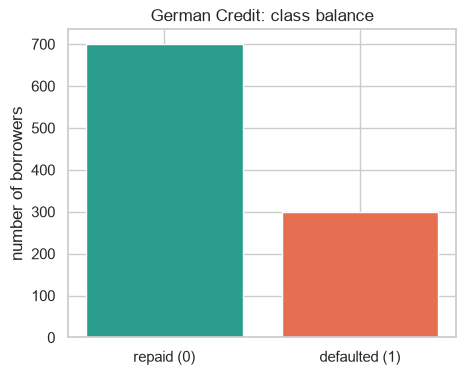

In [9]:
counts = df["default"].value_counts().sort_index()
rates = df["default"].value_counts(normalize=True).sort_index()
print("counts:\n", counts.to_string())
print("\nproportions:\n", rates.round(3).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["repaid (0)", "defaulted (1)"], counts.values, color=["#2a9d8f", "#e76f51"])
ax.set_title("German Credit: class balance")
ax.set_ylabel("number of borrowers")
plt.show()

### The accuracy trap

There are 700 repayers and 300 defaulters. Imagine the laziest possible "model" that ignores the
input and **always predicts 0 (repaid)**. It never catches a single defaulter — useless to a bank —
yet it is right 700 out of 1000 times.

**TODO (YOU):** compute that lazy model's accuracy directly from the data. Fill in the blank so it
prints the fraction of borrowers who did NOT default. (Hint: it's `1 - df["default"].mean()`, but
try to reason why before you type it.)

In [10]:
# TODO (YOU): replace the ... with an expression using df["default"]
baseline_accuracy = 1-df["default"].mean()         # fraction of borrowers who did not default
print(f"'always predict repaid' accuracy = {baseline_accuracy:.1%}")
print("A bank cannot use this model: it approves everyone, including every defaulter.")

'always predict repaid' accuracy = 70.0%
A bank cannot use this model: it approves everyone, including every defaulter.


Hold onto that number. When our real models come in Phase 2, their accuracy has to be judged
*against this baseline*, not against zero. This is exactly why we'll switch to **AUC**, **KS**, and
**Gini** — metrics that measure how well a model *separates* defaulters from repayers, regardless of
the imbalance. We'll define each one when we build the first model.

## 7. Numeric feature distributions

Three numeric features drive most of the intuition: how long the loan is (`duration_months`), how
big it is (`credit_amount`), and how old the borrower is (`age_years`). Let's look at their shapes.

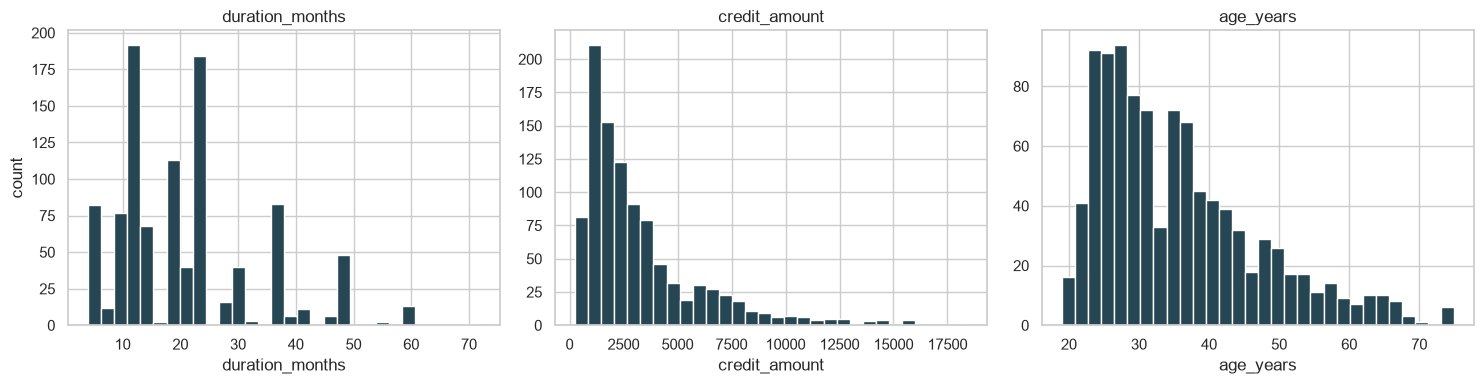

In [11]:
num_cols = ["duration_months", "credit_amount", "age_years"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=30, color="#264653", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

`credit_amount` is clearly right-skewed: most loans are small, a long tail of large ones.
Skew matters later because some models and encodings behave better on roughly symmetric inputs;
a common fix is a log transform. We'll revisit this in feature engineering.

## 8. The key move: default rate by category

For each category of a feature, what fraction of those borrowers defaulted? If a feature's
categories have very different default rates, that feature is **predictive**. `checking_status` is
the classic strong predictor in this dataset.

                   n  default_rate
checking_status                   
< 0 DM           274         0.493
0-200 DM         269         0.390
>= 200 DM         63         0.222
no account       394         0.117


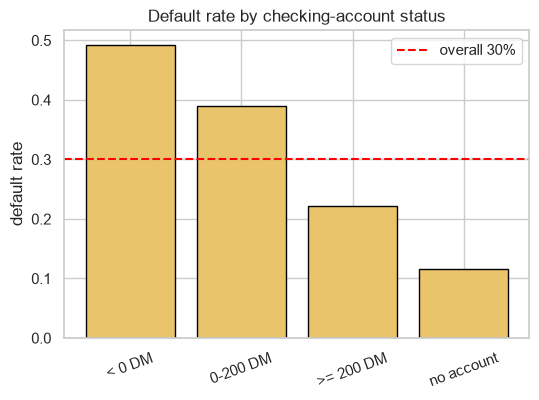

In [12]:
def default_rate_by(col):
    """Return a table: category, count, and default rate, sorted by default rate."""
    g = df.groupby(col)["default"].agg(n="count", default_rate="mean")
    return g.sort_values("default_rate", ascending=False)

rate_checking = default_rate_by("checking_status")
print(rate_checking.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
overall = df["default"].mean()
ax.bar(rate_checking.index, rate_checking["default_rate"], color="#e9c46a", edgecolor="black")
ax.axhline(overall, color="red", linestyle="--", label=f"overall {overall:.0%}")
ax.set_title("Default rate by checking-account status")
ax.set_ylabel("default rate")
ax.legend()
plt.xticks(rotation=20)
plt.show()

Read that chart: borrowers with **no checking account** default far less than borrowers whose
balance is **< 0 DM**. That gap is signal the model will learn. The red line is the overall 30%
default rate for reference — categories above it are riskier than average, below it are safer.

This "default rate vs overall rate" comparison is the seed of **Weight of Evidence (WoE)** encoding,
the Phase 1 theory topic. WoE just turns each of these gaps into a number the model can use directly.
We'll build it next session.

**TODO (YOU):** pick another categorical feature and look at its default rate. Good candidates:
`savings_status`, `employment_since`, `credit_history`, or `housing`. Call `default_rate_by(...)`
with your choice and print the result. Then answer for yourself: does this feature look predictive
(big spread in default rates) or weak (all categories near 30%)?

In [13]:
# TODO (YOU): call default_rate_by(...) on a categorical column of your choice and print it
your_choice = "credit_history"   # e.g. "savings_status"
result = default_rate_by(your_choice)
print(result.round(3).to_string())

                          n  default_rate
credit_history                           
no credits/all paid      40         0.625
all paid this bank       49         0.571
paid duly till now      530         0.319
past delays              88         0.318
critical/other credits  293         0.171


## 9. Recap — what you just learned

- A raw credit dataset is coded; **decoding into readable labels** is step one.
- The target is **imbalanced** (700/300 here), so **accuracy is misleading** — you computed the
  ~70% baseline an approve-everyone model gets for free.
- Numeric features like `credit_amount` are often **skewed**.
- **Default rate by category** is the core EDA move: it reveals which features separate good from
  bad borrowers, and it's the intuition behind Weight of Evidence encoding.

**Next session:** Weight of Evidence (WoE) and Information Value (IV) — turning these default-rate
gaps into model-ready numbers and ranking features by predictive power. Then we download
*Give Me Some Credit* and repeat this EDA at 250x the scale.